In [1]:
import numpy as np

## VECTOR OPERATIONS

Multiplication of a vector by a number (a scalar): we multiply every element of the vector by that number. If we multiply the u by 2:

In [2]:
u = np.array([2, 4, 5, 6])
u * 2

array([ 4,  8, 10, 12])

Vector here is like column - a column vector. This is just a notation: vector are typically written as columns, not rows. In NumPy, the vectors are actually roes. It does not matter for the math - it is the convention for how things are usually written.

Addition works element=wise: we add each element of the first vector to the corresponsding element of the second vector:

In [3]:
v = np.array([1, 0, 0, 2])
u + v

array([3, 4, 5, 8])

Element-wise addition,and multiplication by 2 is element-wise multiplication. What happens in linear algebra here is exactly what NumPy does.

## MULTIPLICATION

### Vector-vector multiplication

Vector-vector multiplication is also called the dot product, or sometimes the inner product. In NumPy u * v multiplies elements elemt-wise:

In [4]:
u*v

array([ 2,  0,  0, 12])

The dot product on the other hand, produces a number. The way we compute it: we multiply each element of u with the correspoding element of v, and then we sum the results:

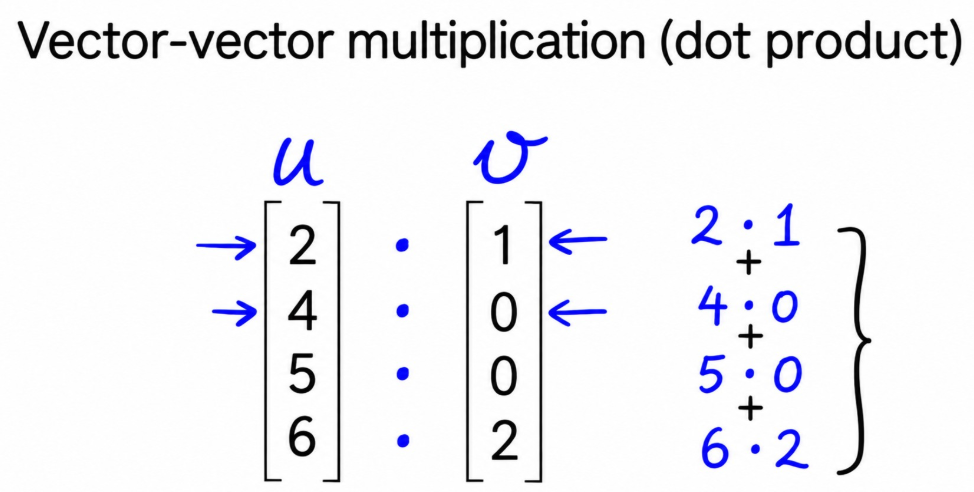

The formula: we have a sum that goes over all elements of our vectors, from 1 to n, where n is the dimension of the vector, and inside we multiply the i-th element of **u** with the i-th element of **v**.

The way we usually write the dot product in linear algebra may not be intuitive at first: u is a column vector, and we write u transposed next to v. The transpose operation turns columns into rows - so we have a row vector times a column vector, and this is just notation for the dot product.

Implementation of function that does vector-vector multiplication for two vector u and v:

In [5]:
def vector_vector_multiplication(u,v):
    assert u.shape[0] == v.shape[0]
    n = u.shape[0]

    result = 0.0

    for i in range(n):
        result = result + u[i] * v[i]

    return result

In [6]:
vector_vector_multiplication(u,v)

np.float64(14.0)

In numpy ther is alreaady a function that does this - **dot**:

In [7]:
u.dot(v)

np.int64(14)

### Matrix-vector multiplication

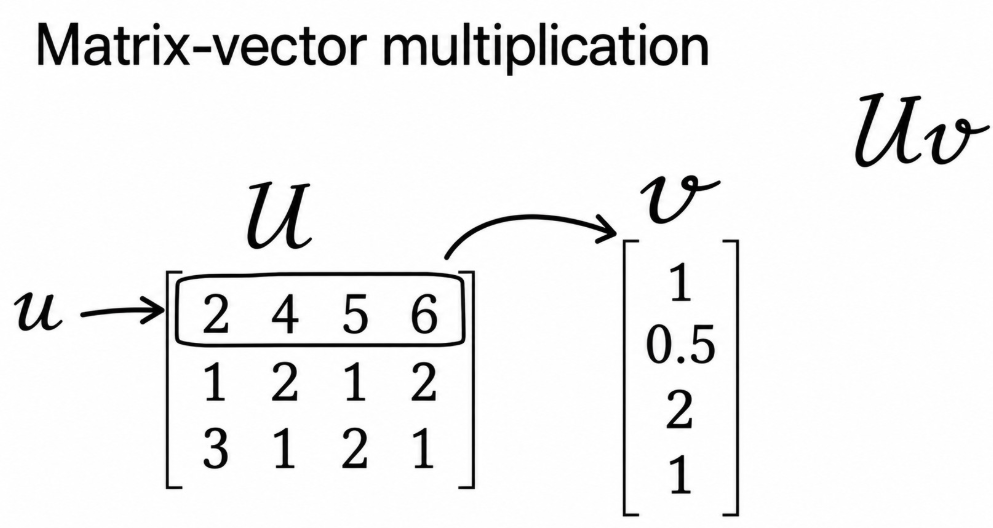

For each row we do a vector-vector multiplication with **v**, and these result together are the answer. So if **U** has k rows - **U[0]** to 
**U[k-1]** - the result is k dot products, one per row. Of course the dimensionality should match: each row of U and the vector v must have the same number of elements, say n.


Implementation in Python:

In [8]:
>>> U = np.array([
    [2, 4, 5, 6],
    [1, 2, 1, 2],
    [3, 1, 2, 1],
    ])

U.shape

(3, 4)

In [9]:
def matrix_vector_multiplication(U, v):
    assert U.shape[1] == v.shape[0]

    num_rows = U.shape[0]

    result = np.zeros(num_rows)

    for i in range(num_rows):
        result[i] = vector_vector_multiplication(U[i], v)

    return result

First, make sure the dimensionalities match. We are interested in number of colums of **U** -  remember, the number of colums in **U** is the dimenstionality of each row of **U**, and it should match the number of elements in **v**.

The  number of rows of **U** is hte dimensionality of the resulting vector: there are three rows in the matrix, so the result of the multiplication has three elements. We initialize it with zeros and, for  each row, compute the vector-vector nultiplication with v, and put it into the result.

In [10]:
matrix_vector_multiplication(U, v)

array([14.,  5.,  5.])

We get a one-dimensional array - a vector. In NumPy we do not want ot write this function every time: we use **dot** again. Because we invoke it on a two-dimensional array, NumPy knows it needs to do a matrix-vector product.

In [11]:
U.dot(v)

array([14,  5,  5])

### Matrix-Matrix multiplication

Finally, matrix-matrix multiplication. We have a matrix **U** and a matrix **V**, and we amnto compute U times V.

What we do here: we take the matrix **V** and break it down into multiple comlumns - **V[:,0], V[:,1], V[:,2]**. Then for each column of v, we mltiply the eniter matrix **U** by this column. Each such multplication is matrix-vector multiplication - we just learned how to do that. The results become the columns of the new matrix.

So matrix-matrix multiplication is represented as a bunch of matrix-vector multiplications. The resulting matrix has the number of rows coming forn **U** and the number of columns coming from **V**. 


In [13]:
V = np.array([
    [1, 1, 2],
     [0, 0.5, 1], 
     [0, 2, 1],
     [2, 1, 0],
 ])

In [18]:
def matrix_matrix_multiplication(U, V):
    assert U.shape[1] == V.shape[0]

    num_rows = U.shape[0]
    num_cols = V.shape[1]

    result = np.zeros((num_rows, num_cols))

    for i in range (num_cols):
        vi = V[:, i]
        Uvi = matrix_vector_multiplication(U, vi)
        result[:, i] = Uvi

    return result

The assertion chec that we can multiply a row of U with a column of V - that's the cehck that makes sure the multiplication makes sense. The result is a matrix of zeros with the number of rows coming from U and the number of columns coming from V. Then we loop over the  columns of V, take  the i-th column - all the rows, i-th column - copute the matrix-vector multilication U time this  coulumn, and put the result into the i-th column of the result matrix. At the end we return the result.

In [19]:
matrix_matrix_multiplication(U, V)

array([[14. , 20. , 13. ],
       [ 5. ,  6. ,  5. ],
       [ 5. ,  8.5,  9. ]])

If we want to multiply two matrices with plain NumPy, we use **dot** method:

In [20]:
U.dot(V)

array([[14. , 20. , 13. ],
       [ 5. ,  6. ,  5. ],
       [ 5. ,  8.5,  9. ]])

## Identity matrix

The identity matrix is a square matrix where oon the diagonal we one and zeros everywhere else:

In [21]:
I = np.eye(3)
I

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

Why is it useful? When we take any matrix - say **U** - and multiply it by I(dimensions should match), we get **U** back. And it does not matter on which side we put ir - we still get **U** back.

The identity matrix is like the number one: if we multiply any number by one, we get the number back. This is the same thing but for matrices.

In NumPy we create with the **eye** functio: we specify the dimension, and it gives us a matrix with ones on the diagonal and zeros everywhere else. Our **V** has three columns, so to test it we need a 3-by-3 identity matrix:

In [23]:
V.dot(I)

array([[1. , 1. , 2. ],
       [0. , 0.5, 1. ],
       [0. , 2. , 1. ],
       [2. , 1. , 0. ]])

## Inverse

The identity matrix is useful for explaining what a matrix inverse is. Let's say we have a matrix A. The inverse of A, usually writen as $A^{-1}$, is a matrix such that we multiply it by A, we get I.

First of all, only square matrices - matrices where the number of rows equals the number of columns - have an inverse. Our V is 4-by-3, so let's take its first three rows to get a square matrix:

In [25]:
Vs = V[[0, 1, 2]]
Vs

array([[1. , 1. , 2. ],
       [0. , 0.5, 1. ],
       [0. , 2. , 1. ]])

To compute the inverse we use a method from NumPy called **inv**. It lives in the **linalg** package, which stands for linear algebra:

In [27]:
Vs_inv = np.linalg.inv(Vs)
Vs_inv

array([[ 1.        , -2.        ,  0.        ],
       [ 0.        , -0.66666667,  0.66666667],
       [ 0.        ,  1.33333333, -0.33333333]])

And when we multiply the inverse by the matrix, what we get is the identity matrix:

In [29]:
Vs_inv.dot(Vs)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])